# Notebook 04 -- STFormer (From Scratch)

**Paper**: *STFormer: Spatio-Temporal Transformer Network for Traffic Flow Prediction*  
**IEEE CyberSciTech 2024** -- Li et al.

```
Input (B, T=12, N=207)
       |
  Closeness Branch          Period Branch
  TemporalTokenizer         TemporalTokenizer
  R x STR-Unit              R x STR-Unit
       \                       /
        alpha*Close + beta*Period   (learnable fusion)
                   |
            Prediction Head
                   |
           Output (B, N=207)
```

**Key fix vs original**: `SpatialTransformerBlock` stays in `(B, T, d_model)` space -- no transpose, no shape mismatch.

---

In [8]:
import sys, os, warnings, pickle
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from utils.data_utils  import load_processed, make_loaders, inverse_transform
from utils.metrics     import compute_all_metrics, print_metrics
from utils.train_utils import EarlyStopping, full_train, predict_all, count_parameters

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU


In [9]:
X_train, y_train, X_val, y_val, X_test, y_test, scaler = load_processed('../data/processed')

train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test,
    batch_size_train=8, batch_size_eval=32   # paper uses batch=8
)

T_IN      = X_train.shape[1]   # 12
N_SENSORS = X_train.shape[2]   # 207
print(f'T_in={T_IN}, N_sensors={N_SENSORS}')

[load] Loaded processed data from ../data/processed\processed_data.pkl
[loaders] Train:23978  Val:3415  Test:6843
T_in=12, N_sensors=207


## 1. Building Blocks

### 1a. Temporal Tokenizer

In [10]:
class TemporalTokenizer(nn.Module):
    """
    Input  (B, T, N) -> Output (B, T, d_model)
    Linear patch embed + learnable positional encoding.
    """
    def __init__(self, n_sensors, d_model, t_in, dropout=0.1):
        super().__init__()
        self.patch_embed = nn.Linear(n_sensors, d_model)
        self.pos_embed   = nn.Parameter(torch.zeros(1, t_in, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.patch_embed(x) + self.pos_embed
        return self.dropout(self.norm(x))

### 1b. Temporal Transformer Block

In [11]:
class TemporalTransformerBlock(nn.Module):
    """
    Pre-norm Transformer over the TIME axis.
    Input/Output: (B, T, d_model)
    """
    def __init__(self, d_model, n_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, ff_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model), nn.Dropout(dropout)
        )

    def forward(self, x):
        xn = self.norm1(x)
        x  = x + self.attn(xn, xn, xn)[0]
        x  = x + self.ffn(self.norm2(x))
        return x

### 1c. Spatial Transformer Block (Fixed)

**Root cause of original error**: transposing to `(B, d_model, T)` caused `LayerNorm([64])` to see last dim=12 (T) instead of 64.  
**Fix**: stay entirely in `(B, T, d_model)` space. Project `x_raw (B,T,N)` to `(B,T,d_model)` and use cross-attention.

In [12]:
class SpatialTransformerBlock(nn.Module):
    """
    Spatial cross-attention -- stays in (B, T, d_model) space.

    x_raw (B, T, N) --[Linear]--> spatial context (B, T, d_model)
    Temporal features QUERY the spatial context via cross-attention.

    Input : x     (B, T, d_model)  -- temporal features
            x_raw (B, T, N)        -- original sensor readings
    Output: (B, T, d_model)
    """
    def __init__(self, d_model, n_heads, ff_dim, n_sensors, dropout=0.1):
        super().__init__()
        self.spatial_proj = nn.Linear(n_sensors, d_model)  # N -> d_model
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, ff_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model)
        )

    def forward(self, x, x_raw):
        # Project sensor readings to d_model (spatial context)
        spatial = self.spatial_proj(x_raw)   # (B, T, d_model)
        # Cross-attention: Q=temporal, K/V=spatial
        xn = self.norm1(x)
        sn = self.norm1(spatial)
        x  = x + self.attn(xn, sn, sn)[0]
        x  = x + self.ffn(self.norm2(x))
        return x   # (B, T, d_model)

### 1d. Spatio-Temporal Residual Unit (STR-Unit)

In [13]:
class STResidualUnit(nn.Module):
    """One STR-Unit: Temporal Transformer + Spatial Transformer + residual."""
    def __init__(self, d_model, n_heads, ff_dim, n_sensors, dropout=0.1):
        super().__init__()
        self.temporal = TemporalTransformerBlock(d_model, n_heads, ff_dim, dropout)
        self.spatial  = SpatialTransformerBlock(d_model, n_heads, ff_dim, n_sensors, dropout)
        self.res_proj = nn.Linear(d_model, d_model)

    def forward(self, x, x_raw):
        residual = x
        x = self.temporal(x)
        x = self.spatial(x, x_raw)
        x = x + self.res_proj(residual)
        return x

### 1e. Full STFormer Model

In [14]:
class STFormer(nn.Module):
    """
    STFormer -- IEEE CyberSciTech 2024
    Hyperparams: d_model=64, n_heads=4, n_residual=2, lr=3e-4, batch=8
    """
    def __init__(self, n_sensors=207, t_in=12, d_model=64, n_heads=4,
                 n_residual=2, ff_dim=256, dropout=0.1):
        super().__init__()
        # Closeness branch
        self.close_tokenizer = TemporalTokenizer(n_sensors, d_model, t_in, dropout)
        self.close_stblocks  = nn.ModuleList([
            STResidualUnit(d_model, n_heads, ff_dim, n_sensors, dropout)
            for _ in range(n_residual)
        ])
        # Period branch
        self.period_tokenizer = TemporalTokenizer(n_sensors, d_model, t_in, dropout)
        self.period_stblocks  = nn.ModuleList([
            STResidualUnit(d_model, n_heads, ff_dim, n_sensors, dropout)
            for _ in range(n_residual)
        ])
        # Learnable fusion weights alpha, beta
        self.alpha = nn.Parameter(torch.ones(1, t_in, d_model) * 0.5)
        self.beta  = nn.Parameter(torch.ones(1, t_in, d_model) * 0.5)
        # Prediction head
        self.pred_head = nn.Sequential(
            nn.Tanh(),
            nn.Flatten(start_dim=1),
            nn.Linear(t_in * d_model, n_sensors),
        )

    def _run_component(self, tokenizer, blocks, x):
        tokens = tokenizer(x)
        for block in blocks:
            tokens = block(tokens, x)
        return tokens

    def forward(self, x):
        close_out  = self._run_component(self.close_tokenizer,  self.close_stblocks,  x)
        period_out = self._run_component(self.period_tokenizer, self.period_stblocks, x)
        fused = self.alpha * close_out + self.beta * period_out
        return self.pred_head(fused)   # (B, N)


# Build model
model = STFormer(
    n_sensors=N_SENSORS, t_in=T_IN, d_model=64,
    n_heads=4, n_residual=2, ff_dim=256, dropout=0.1
).to(device)

print(f'Parameters: {count_parameters(model):,}')

# Shape check
with torch.no_grad():
    dummy = torch.randn(4, T_IN, N_SENSORS).to(device)
    out   = model(dummy)
    print(f'Input  : {tuple(dummy.shape)}')
    print(f'Output : {tuple(out.shape)}  <- should be (4, 207)')
    assert out.shape == (4, N_SENSORS), 'Shape mismatch!'
    print('Shape check PASSED!')

Parameters: 658,895
Input  : (4, 12, 207)
Output : (4, 207)  <- should be (4, 207)
Shape check PASSED!


## 2. Training (Paper: lr=3e-4, batch=8)

In [15]:
criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5, min_lr=1e-6)
early_stop = EarlyStopping(patience=15, path='../models/stformer_best.pth')

train_losses, val_losses = full_train(
    model, train_loader, val_loader,
    optimizer, criterion, scheduler, early_stop,
    device, max_epochs=100, model_name='STFormer'
)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Training STFormer on cuda
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Epoch    1/100 | train=0.026969 | val=0.020621
  ✓ Best model saved → ../models/stformer_best.pth  (val_loss=0.020621)
  ✓ Best model saved → ../models/stformer_best.pth  (val_loss=0.016817)
  ✓ Best model saved → ../models/stformer_best.pth  (val_loss=0.015191)
  ✓ Best model saved → ../models/stformer_best.pth  (val_loss=0.012875)
  Epoch    5/100 | train=0.011916 | val=0.012925
  EarlyStopping counter: 1/15
  ✓ Best model saved → ../models/stformer_best.pth  (val_loss=0.012536)
  ✓ Best model saved → ../models/stformer_best.pth  (val_loss=0.011964)
  ✓ Best model saved → ../models/stformer_best.pth  (val_loss=0.011923)
  ✓ Best model saved → ../models/stformer_best.pth  (val_loss=0.011280)
  Epoch   10/100 | train=0.010755 | val=0.011215
  ✓ Best model saved → ../models/stformer_best.pth  (val_loss=0.011215)
  EarlyStopping counter: 1/15
  EarlyStoppin

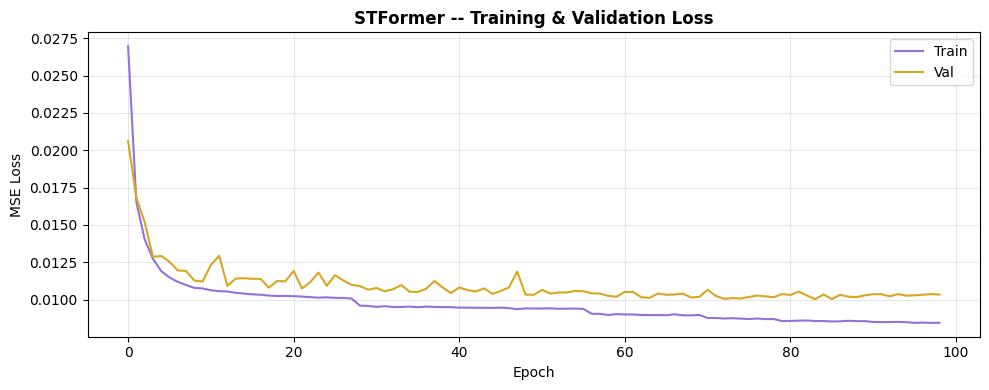

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train', color='mediumpurple', lw=1.5)
ax.plot(val_losses,   label='Val',   color='goldenrod',   lw=1.5)
ax.set_title('STFormer -- Training & Validation Loss', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/stformer_training_curve.png', dpi=150)
plt.show()

## 3. Evaluation

In [17]:
preds_norm, labels_norm = predict_all(model, test_loader, device)
preds  = inverse_transform(preds_norm, scaler)
labels = inverse_transform(labels_norm, scaler)

metrics = compute_all_metrics(preds, labels)
print_metrics(metrics, 'STFormer (From Scratch)')

os.makedirs('../results', exist_ok=True)
with open('../results/stformer_metrics.pkl', 'wb') as f:
    pickle.dump({'model': 'STFormer (Scratch)', 'metrics': metrics,
                 'train_losses': train_losses, 'val_losses': val_losses,
                 'params': count_parameters(model)}, f)
print('Saved -> results/stformer_metrics.pkl')


  STFormer (From Scratch) — Evaluation Metrics
  MAE  : 4.5524 km/h
  RMSE : 8.6533 km/h
  MAPE : 9.28 %
  R²   : 0.8557

Saved -> results/stformer_metrics.pkl


## 4. Visualizations

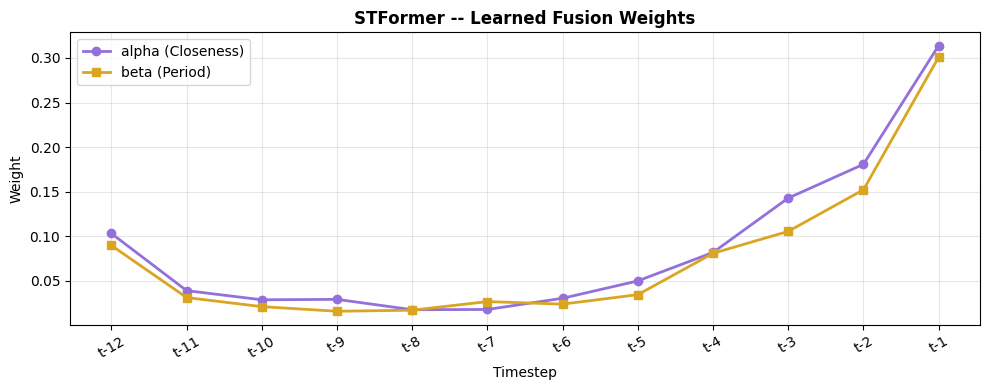

In [18]:
# Fusion weights alpha and beta
alpha_w = model.alpha.detach().cpu().squeeze().mean(dim=-1)
beta_w  = model.beta.detach().cpu().squeeze().mean(dim=-1)

fig, ax = plt.subplots(figsize=(10, 4))
steps = range(1, T_IN + 1)
ax.plot(steps, alpha_w.numpy(), 'o-', label='alpha (Closeness)', color='mediumpurple', lw=2)
ax.plot(steps, beta_w.numpy(),  's-', label='beta (Period)',     color='goldenrod',    lw=2)
ax.set_title('STFormer -- Learned Fusion Weights', fontweight='bold')
ax.set_xlabel('Timestep'); ax.set_ylabel('Weight')
ax.set_xticks(range(1, T_IN+1))
ax.set_xticklabels([f't-{T_IN-i}' for i in range(T_IN)], rotation=30)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/stformer_fusion_weights.png', dpi=150)
plt.show()

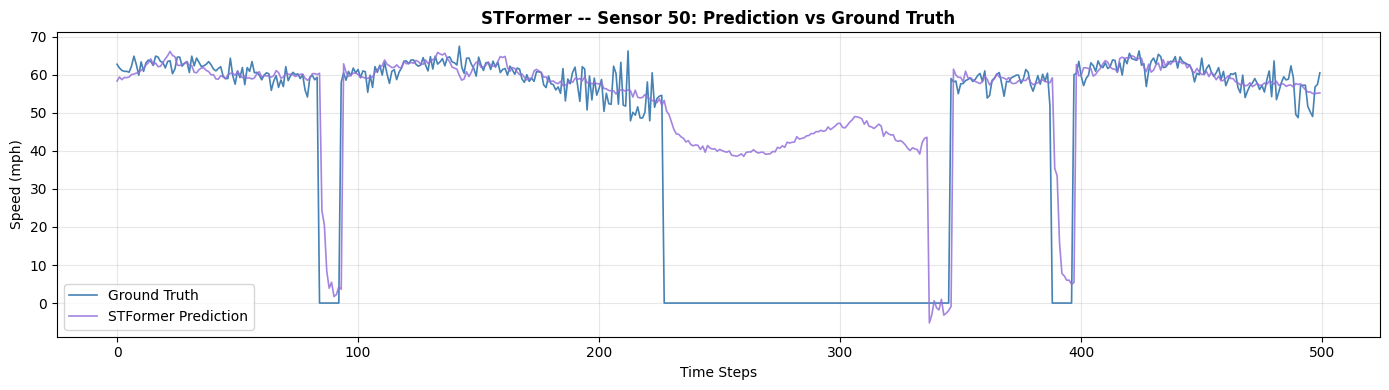

In [19]:
# Prediction vs Ground Truth
sensor_idx = 50
n_show     = 500

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(labels[:n_show, sensor_idx], label='Ground Truth',       color='steelblue',   lw=1.2)
ax.plot(preds[:n_show,  sensor_idx], label='STFormer Prediction', color='mediumpurple', lw=1.2, alpha=0.85)
ax.set_title(f'STFormer -- Sensor {sensor_idx}: Prediction vs Ground Truth', fontweight='bold')
ax.set_xlabel('Time Steps'); ax.set_ylabel('Speed (mph)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/stformer_prediction_viz.png', dpi=150)
plt.show()